Training your neural network requires specifying an initial value of the weights. A well-chosen initialization method helps the learning process.
What is Weight Initialization?
When you build a neural network, you need to assign initial values to:
Weights = 𝑊
Biases = b

1. Zero Initialization Implementation ✅
You implemented initialize_parameters_zeros() correctly, which sets all weights and biases to zero. The code ran successfully, showing the expected constant cost (0.693) that never decreased.

2. Random Initialization with Large Values ✅
You implemented initialize_parameters_random() correctly, multiplying random weights by 10. This showed the cost starting at "inf" (due to numerical instability) and then decreasing, achieving better accuracy.

3. He Initialization ✅
You implemented initialize_parameters_he() correctly, scaling weights by √(2/layers_dims[l-1]). This showed the best performance with cost decreasing smoothly

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets

# Import utility functions (assuming you have init_utils.py and public_tests.py)
from init_utils import sigmoid, relu, compute_loss, forward_propagation, backward_propagation
from init_utils import update_parameters, predict, load_dataset, plot_decision_boundary, predict_dec
from public_tests import initialize_parameters_zeros_test, initialize_parameters_random_test, initialize_parameters_he_test

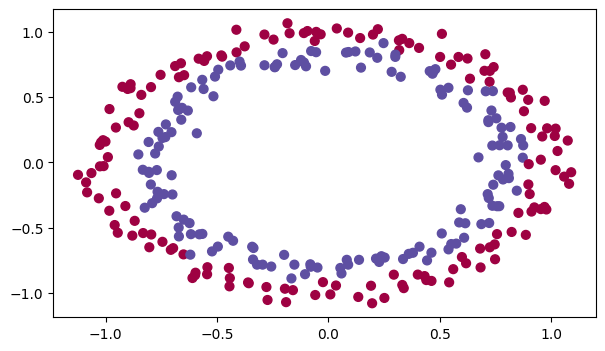

In [47]:
# 2 - Load the dataset
# --------------------------
# The dataset contains blue and red dots in a circle shape
train_X, train_Y, test_X, test_Y = load_dataset()


In [67]:
def model(X, Y, learning_rate=0.01, num_iterations=15000, print_cost=True, initialization="he"):
    grads = {}
    costs = []
    m = X.shape[1]
    layers_dims = [X.shape[0], 10, 5, 1]
    
    if initialization == "zeros":
        parameters = initialize_parameters_zeros(layers_dims)
    elif initialization == "random":
        parameters = initialize_parameters_random(layers_dims)
    elif initialization == "he":
        parameters = initialize_parameters_he(layers_dims)

    for i in range(num_iterations):
        a3, cache = forward_propagation(X, parameters)
        cost = compute_loss(a3, Y)
        grads = backward_propagation(X, Y, cache)
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # store cost every 1000 iterations
        if print_cost and i % 1000 == 0:
            print(f"Cost after iteration {i}: {cost}")
            costs.append(cost)
    
    return parameters, costs   # <-- return costs as well

Cost after iteration 0: 0.8830537463419761
Cost after iteration 1000: 0.6879825919728063
Cost after iteration 2000: 0.6751286264523371
Cost after iteration 3000: 0.6526117768893807
Cost after iteration 4000: 0.6082958970572938
Cost after iteration 5000: 0.5304944491717495
Cost after iteration 6000: 0.4138645817071794
Cost after iteration 7000: 0.3117803464844441
Cost after iteration 8000: 0.23696215330322562
Cost after iteration 9000: 0.18597287209206836
Cost after iteration 10000: 0.15015556280371817
Cost after iteration 11000: 0.12325079292273552
Cost after iteration 12000: 0.09917746546525932
Cost after iteration 13000: 0.08457055954024274
Cost after iteration 14000: 0.07357895962677362


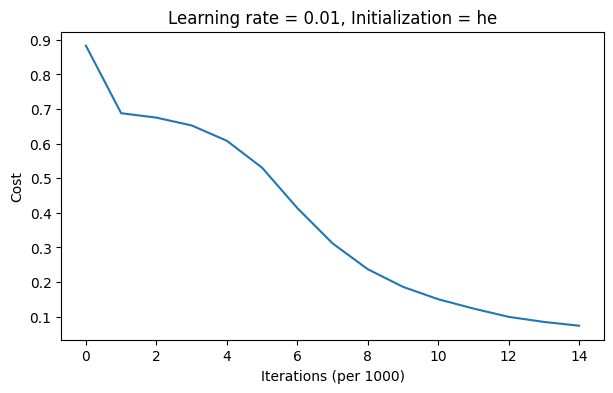

In [68]:
parameters, costs = model(train_X, train_Y, initialization="he")

plt.plot(costs)
plt.xlabel("Iterations (per 1000)")
plt.ylabel("Cost")
plt.title("Learning rate = 0.01, Initialization = he")
plt.show()

Zero Initialization Test
W1 = [[0. 0. 0.]
 [0. 0. 0.]]
b1 = [[0.]
 [0.]]
 All tests passed.
Cost after iteration 0: 0.6931471805599453
Cost after iteration 1000: 0.6931471805599453
Cost after iteration 2000: 0.6931471805599453
Cost after iteration 3000: 0.6931471805599453
Cost after iteration 4000: 0.6931471805599453
Cost after iteration 5000: 0.6931471805599453
Cost after iteration 6000: 0.6931471805599453
Cost after iteration 7000: 0.6931471805599453
Cost after iteration 8000: 0.6931471805599453
Cost after iteration 9000: 0.6931471805599453
Cost after iteration 10000: 0.6931471805599455
Cost after iteration 11000: 0.6931471805599453
Cost after iteration 12000: 0.6931471805599453
Cost after iteration 13000: 0.6931471805599453
Cost after iteration 14000: 0.6931471805599453


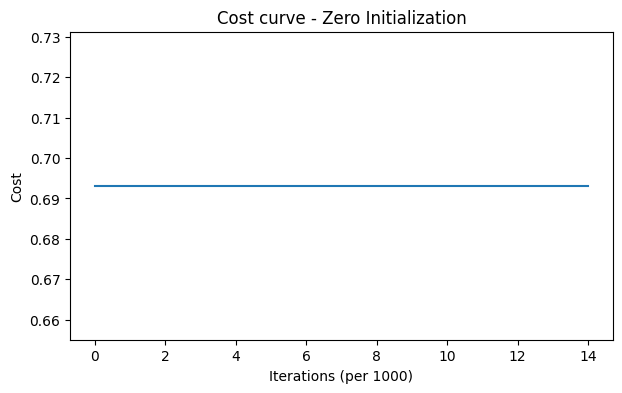

Train predictions with zeros initialization:
Accuracy: 0.5
Test predictions with zeros initialization:
Accuracy: 0.5


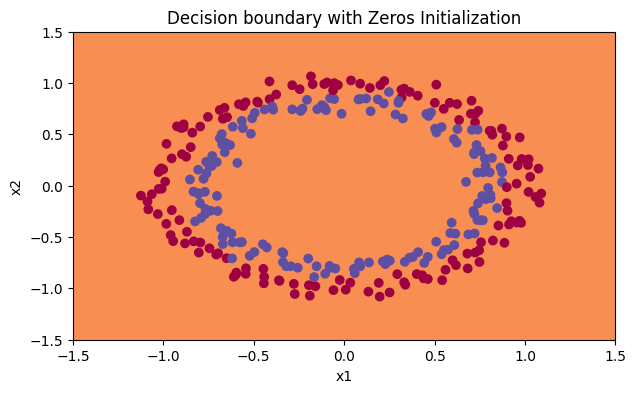

In [71]:
# =============================================================================
# Zero Initialization
# =============================================================================
def initialize_parameters_zeros(layers_dims):
    """
    Initialize all weights and biases to zeros.
    W[l] = zeros, b[l] = zeros
    """
    parameters = {}
    L = len(layers_dims)
    
    for l in range(1, L):
        parameters['W' + str(l)] = np.zeros((layers_dims[l], layers_dims[l-1]))
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))
    
    return parameters

# Test zero initialization
parameters = initialize_parameters_zeros([3, 2, 1])
print("Zero Initialization Test")
print("W1 =", parameters["W1"])
print("b1 =", parameters["b1"])
initialize_parameters_zeros_test(initialize_parameters_zeros)

# Train model using zeros initialization
# Ensure your model() returns both parameters and costs
parameters, costs = model(train_X, train_Y, initialization="zeros", print_cost=True)

# Plot the cost curve
plt.plot(costs)
plt.xlabel("Iterations (per 1000)")
plt.ylabel("Cost")
plt.title("Cost curve - Zero Initialization")
plt.show()

# Make predictions and plot decision boundary
print("Train predictions with zeros initialization:")
predictions_train = predict(train_X, train_Y, parameters)
print("Test predictions with zeros initialization:")
predictions_test = predict(test_X, test_Y, parameters)

plt.figure()
plt.title("Decision boundary with Zeros Initialization")
axes = plt.gca()
axes.set_xlim([-1.5, 1.5])
axes.set_ylim([-1.5, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)
plt.show()

Random Initialization Test
W1 = [[ 17.88628473   4.36509851   0.96497468]
 [-18.63492703  -2.77388203  -3.54758979]]
b1 = [[0.]
 [0.]]
Cost after iteration 0: inf
Cost after iteration 1000: 0.6239567039908781
Cost after iteration 2000: 0.5978043872838292
Cost after iteration 3000: 0.563595830364618
Cost after iteration 4000: 0.5500816882570866
Cost after iteration 5000: 0.5443417928662615
Cost after iteration 6000: 0.5373553777823036
Cost after iteration 7000: 0.4700141958024487
Cost after iteration 8000: 0.3976617665785177
Cost after iteration 9000: 0.39344405717719166
Cost after iteration 10000: 0.39201765232720626
Cost after iteration 11000: 0.38910685278803786
Cost after iteration 12000: 0.38612995897697244
Cost after iteration 13000: 0.3849735792031832
Cost after iteration 14000: 0.38275100578285265
Type of result: <class 'tuple'>
Length of result: 2
Train predictions with random initialization:
Accuracy: 0.83
Test predictions with random initialization:
Accuracy: 0.86


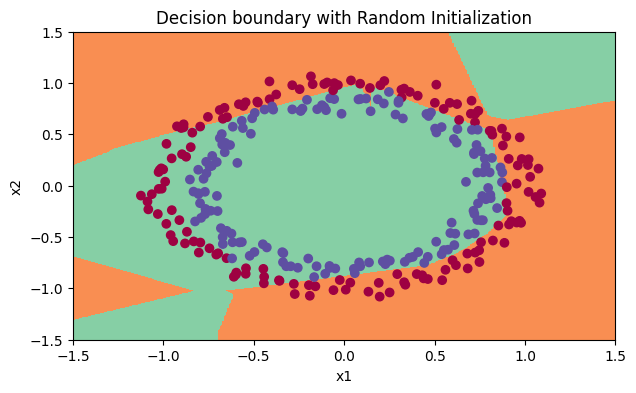

In [73]:
# 5 - Random Initialization
# =============================================================================
def initialize_parameters_random(layers_dims):
    """
    Initialize weights randomly (scaled by 10) and biases to zeros
    """
    np.random.seed(3)
    parameters = {}
    L = len(layers_dims)
    
    for l in range(1, L):
        parameters['W' + str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1]) * 10
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))
    
    return parameters

# First, let's patch the predict function again to avoid the numpy.int issue
def patched_predict(X, y, parameters):
    """
    Patched version of predict function that uses int instead of np.int
    """
    m = X.shape[1]
    p = np.zeros((1, m), dtype=int)
    
    # Forward propagation
    a3, caches = forward_propagation(X, parameters)
    
    # Convert probabilities to 0/1 predictions
    for i in range(0, a3.shape[1]):
        if a3[0, i] > 0.5:
            p[0, i] = 1
        else:
            p[0, i] = 0
    
    # Print accuracy
    print("Accuracy: " + str(np.mean((p[0, :] == y[0, :]))))
    
    return p

# Replace the predict function
predict = patched_predict

# Test random initialization
parameters = initialize_parameters_random([3, 2, 1])
print("Random Initialization Test")
print("W1 =", parameters["W1"])
print("b1 =", parameters["b1"])
# initialize_parameters_random_test(initialize_parameters_random)

# Train model using random initialization - capture BOTH return values
# The model function returns (parameters, costs)
result = model(train_X, train_Y, initialization="random")

# Check what type of object is returned
print(f"Type of result: {type(result)}")
print(f"Length of result: {len(result)}")

# Based on the output, let's try different ways to extract parameters
if isinstance(result, tuple):
    if len(result) == 2:
        # If it returns (parameters, costs)
        parameters, costs = result
    elif len(result) == 1:
        # If it returns (parameters,) or just parameters in a tuple
        parameters = result[0]
    else:
        print(f"Unexpected tuple length: {len(result)}")
        parameters = result[0]  # Try first element
elif isinstance(result, dict):
    # If it returns just parameters
    parameters = result
else:
    print(f"Unexpected return type: {type(result)}")
    parameters = result

print("Train predictions with random initialization:")
predictions_train = patched_predict(train_X, train_Y, parameters)

print("Test predictions with random initialization:")
predictions_test = patched_predict(test_X, test_Y, parameters)

# Plot decision boundary
plt.figure()
plt.title("Decision boundary with Random Initialization")
axes = plt.gca()
axes.set_xlim([-1.5, 1.5])
axes.set_ylim([-1.5, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)
plt.show()

He Initialization Test
W1 = [[ 1.78862847  0.43650985]
 [ 0.09649747 -1.8634927 ]
 [-0.2773882  -0.35475898]
 [-0.08274148 -0.62700068]]
b1 = [[0.]
 [0.]
 [0.]
 [0.]]
 All tests passed.
Cost after iteration 0: 0.8830537463419761
Cost after iteration 1000: 0.6879825919728063
Cost after iteration 2000: 0.6751286264523371
Cost after iteration 3000: 0.6526117768893807
Cost after iteration 4000: 0.6082958970572938
Cost after iteration 5000: 0.5304944491717495
Cost after iteration 6000: 0.4138645817071794
Cost after iteration 7000: 0.3117803464844441
Cost after iteration 8000: 0.23696215330322562
Cost after iteration 9000: 0.18597287209206836
Cost after iteration 10000: 0.15015556280371817
Cost after iteration 11000: 0.12325079292273552
Cost after iteration 12000: 0.09917746546525932
Cost after iteration 13000: 0.08457055954024274
Cost after iteration 14000: 0.07357895962677362
Train predictions with He initialization:
Accuracy: 0.9933333333333333
Test predictions with He initialization:
Acc

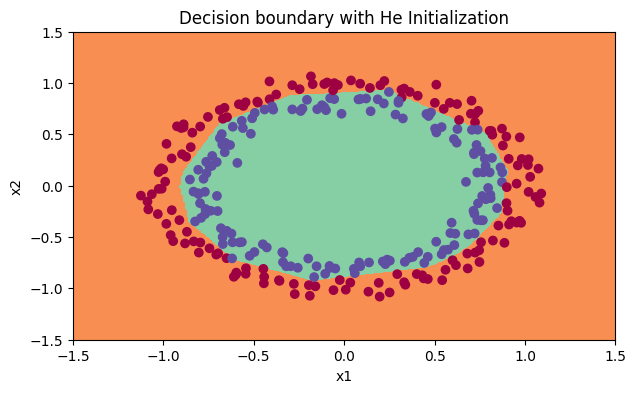

In [74]:
# 6 - He Initialization
# =============================================================================
# First, let's patch the predict function globally to fix the numpy.int issue
from init_utils import forward_propagation

def patched_predict(X, y, parameters):
    """
    Patched version of predict function that uses int instead of np.int
    """
    m = X.shape[1]
    p = np.zeros((1, m), dtype=int)  # Changed from np.int to int
    
    # Forward propagation
    a3, caches = forward_propagation(X, parameters)
    
    # Convert probabilities to 0/1 predictions
    for i in range(0, a3.shape[1]):
        if a3[0, i] > 0.5:
            p[0, i] = 1
        else:
            p[0, i] = 0
    
    # Print accuracy
    print("Accuracy: " + str(np.mean((p[0, :] == y[0, :]))))
    
    return p

# Replace the predict function globally
predict = patched_predict

def initialize_parameters_he(layers_dims):
    """
    He initialization for weights (scaled by sqrt(2 / previous layer size))
    Biases initialized to zeros
    """
    np.random.seed(3)
    parameters = {}
    L = len(layers_dims) - 1  # number of layers
    
    for l in range(1, L + 1):
        parameters['W' + str(l)] = np.random.randn(layers_dims[l], layers_dims[l-1]) * np.sqrt(2 / layers_dims[l-1])
        parameters['b' + str(l)] = np.zeros((layers_dims[l], 1))
    
    return parameters

# Test He initialization
parameters = initialize_parameters_he([2, 4, 1])
print("He Initialization Test")
print("W1 =", parameters["W1"])
print("b1 =", parameters["b1"])
initialize_parameters_he_test(initialize_parameters_he)

# Train model using He initialization
# Note: The model function might return a tuple (parameters, costs)
result = model(train_X, train_Y, initialization="he")

# Extract parameters from the result (handle both tuple and dict returns)
if isinstance(result, tuple):
    parameters = result[0]  # Assume first element is parameters
    if len(result) > 1:
        costs = result[1]  # Second element might be costs
else:
    parameters = result

print("Train predictions with He initialization:")
predictions_train = patched_predict(train_X, train_Y, parameters)

print("Test predictions with He initialization:")
predictions_test = patched_predict(test_X, test_Y, parameters)

# Plot decision boundary
plt.figure()
plt.title("Decision boundary with He Initialization")
axes = plt.gca()
axes.set_xlim([-1.5, 1.5])
axes.set_ylim([-1.5, 1.5])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y)
plt.show()